In [1]:
from typing import List
import itertools
import functools
import numpy as np
import matplotlib.pyplot as plt
import cirq
from encoded.repetition_code import (
    generate_stabilizers,
    encoding_repetition
)
from encoded.expanded_repetition_code import (
    x_bar,
    z_bar,
    stabilizer_generators,
    encoding_expanded_repetition
)
from encoded.symmetry_expansion import symmetry_expansion

Let's prepare the logical $|0\rangle$ state, then subject the qubits to depolarizing noise, then measure logical $Z$.

In [2]:
error_probs = np.linspace(0., 0.4, num=5)

In [3]:
sim = cirq.DensityMatrixSimulator()

In [4]:
def generate_stabilizer_elements(generators: List[cirq.PauliString]) -> List[cirq.PauliString]:
    elements = []
    for string in itertools.chain.from_iterable(itertools.combinations(generators, r) for r in range(len(generators) + 1)):
        elements.append(
            functools.reduce(lambda a, b: a * b, string, cirq.PauliString())
        )
    return elements

## Repetition code

In [5]:
qubits = cirq.LineQubit.range(3)
n = 3
generators = []
for i in range(n-1):
    generators.append(cirq.Z.on(qubits[i]) * cirq.Z.on(qubits[i+1]))
elements = generate_stabilizer_elements(generators)
print(f"The group contains {len(elements)} elements:")
for element in elements:
    print(element)

The group contains 4 elements:
I
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
Z(q(0))*Z(q(2))


In [6]:
noisy_exp_vals = [] # Without mitigation
mitigated_exp_vals = [] # With mitigation
for p in error_probs:
    circuit, qubits = encoding_repetition('0', 3)
    logical_z = cirq.Z.on(qubits[0])
    for q in qubits:
        circuit.append(cirq.depolarize(p=p).on(q))
    noisy_exp_val = sim.simulate_expectation_values(circuit, [logical_z])[0]
    mitigated_exp_val = symmetry_expansion(circuit, logical_z, elements, sim=sim)
    noisy_exp_vals.append(noisy_exp_val)
    mitigated_exp_vals.append(mitigated_exp_val)

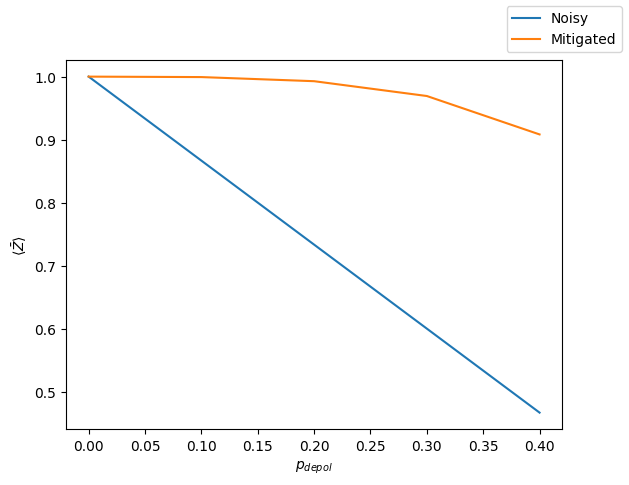

In [7]:
fig, ax = plt.subplots()
ax.plot(error_probs, noisy_exp_vals, label="Noisy")
ax.plot(error_probs, mitigated_exp_vals, label="Mitigated")
ax.set_xlabel(r"$p_{depol}$")
ax.set_ylabel(r"$\langle\bar{Z}\rangle$")
fig.legend()

## Expanded repetition code

In [8]:
qubits = cirq.LineQubit.range(4)
n = len(qubits)
generators = stabilizer_generators
print(f"The group has {len(generators)} generators:")
for generator in generators:
    print(generator)
elements = generate_stabilizer_elements(generators)
print(f"The group contains {len(elements)} elements:")
for element in elements:
    print(element)

The group has 3 generators:
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
X(q(0))*X(q(1))*X(q(2))*X(q(3))
The group contains 8 elements:
I
Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
X(q(0))*X(q(1))*X(q(2))*X(q(3))
Z(q(0))*Z(q(2))
-Y(q(0))*Y(q(1))*X(q(2))*X(q(3))
-X(q(0))*Y(q(1))*Y(q(2))*X(q(3))
-Y(q(0))*X(q(1))*Y(q(2))*X(q(3))


In [9]:
noisy_exp_vals_exp = [] # Without mitigation
mitigated_exp_vals_exp = [] # With mitigation
for p in error_probs:
    circuit, qubits = encoding_expanded_repetition('0')
    for q in qubits:
        circuit.append(cirq.depolarize(p=p).on(q))
    noisy_exp_val = sim.simulate_expectation_values(circuit, [z_bar])[0]
    mitigated_exp_val = symmetry_expansion(circuit, z_bar, elements, sim=sim)
    noisy_exp_vals_exp.append(noisy_exp_val)
    mitigated_exp_vals_exp.append(mitigated_exp_val)

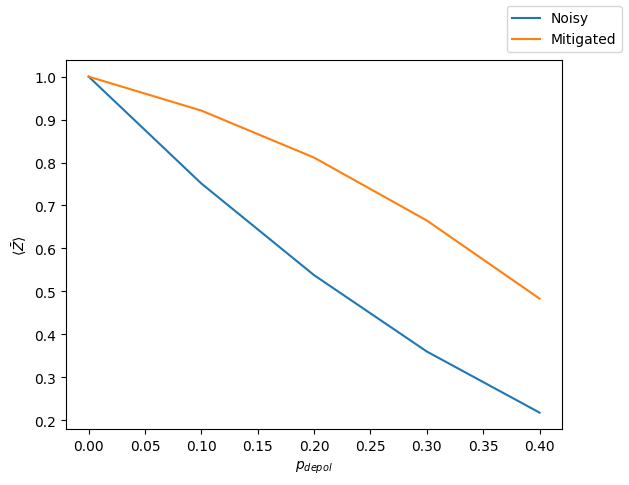

In [10]:
fig, ax = plt.subplots()
ax.plot(error_probs, noisy_exp_vals_exp, label="Noisy")
ax.plot(error_probs, mitigated_exp_vals_exp, label="Mitigated")
ax.set_xlabel(r"$p_{depol}$")
ax.set_ylabel(r"$\langle\bar{Z}\rangle$")
fig.legend()